In [3]:
import sns

from utils.constants import *
import shutil
import kagglehub
"""
pip install kagglehub[pandas-datasets] to download dataset
""" 

os.makedirs('gtrsb_dataset', exist_ok=True)
dataset_path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print(f"Dataset downloaded to: {dataset_path}")

# move the dataset to current project directory
target_path = './gtrsb_dataset'
if os.path.exists(target_path):
    shutil.move(dataset_path, target_path)

'\npip install kagglehub[pandas-datasets] to download dataset\n'

In [2]:
from pathlib import Path
import pandas as pd

# Get the root path of the dataset
DATA_ROOT = Path("gtrsb_dataset") / "1"

# Make dataset tables available in variables
train_df = pd.read_csv(DATA_ROOT / "Train.csv")
test_df = pd.read_csv(DATA_ROOT / "Test.csv")
meta_df = pd.read_csv(DATA_ROOT / "Meta.csv")

# Add a full path column to the dataset
train_df["full_path"] = train_df["Path"].apply(lambda p: str(DATA_ROOT / p))
test_df["full_path"]  = test_df["Path"].apply(lambda p: str(DATA_ROOT / p))

# Display data
print("Training data:")
display(train_df)
print("Testing data:")
display(test_df)

Training data:


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path,full_path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png,gtrsb_dataset\1\Train\20\00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png,gtrsb_dataset\1\Train\20\00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png,gtrsb_dataset\1\Train\20\00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png,gtrsb_dataset\1\Train\20\00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png,gtrsb_dataset\1\Train\20\00020_00000_00004.png
...,...,...,...,...,...,...,...,...,...
39204,52,56,5,6,47,51,42,Train/42/00042_00007_00025.png,gtrsb_dataset\1\Train\42\00042_00007_00025.png
39205,56,58,5,5,51,53,42,Train/42/00042_00007_00026.png,gtrsb_dataset\1\Train\42\00042_00007_00026.png
39206,58,62,5,6,53,57,42,Train/42/00042_00007_00027.png,gtrsb_dataset\1\Train\42\00042_00007_00027.png
39207,63,69,5,7,58,63,42,Train/42/00042_00007_00028.png,gtrsb_dataset\1\Train\42\00042_00007_00028.png


Testing data:


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path,full_path
0,53,54,6,5,48,49,16,Test/00000.png,gtrsb_dataset\1\Test\00000.png
1,42,45,5,5,36,40,1,Test/00001.png,gtrsb_dataset\1\Test\00001.png
2,48,52,6,6,43,47,38,Test/00002.png,gtrsb_dataset\1\Test\00002.png
3,27,29,5,5,22,24,33,Test/00003.png,gtrsb_dataset\1\Test\00003.png
4,60,57,5,5,55,52,11,Test/00004.png,gtrsb_dataset\1\Test\00004.png
...,...,...,...,...,...,...,...,...,...
12625,42,41,5,6,37,36,12,Test/12625.png,gtrsb_dataset\1\Test\12625.png
12626,50,51,6,5,45,46,33,Test/12626.png,gtrsb_dataset\1\Test\12626.png
12627,29,29,6,6,24,24,6,Test/12627.png,gtrsb_dataset\1\Test\12627.png
12628,48,49,5,6,43,44,7,Test/12628.png,gtrsb_dataset\1\Test\12628.png


# What can we see in the dataset?
We can see, that our data has three (six) attributes:
- width: The width of the image
- heigt: The height of the image
- ROI: The region of interest. Defined by the coordinates $(x_1,y_1)$ and $(x_2,y_2)$ that span a box

To get a better idea of it consider the following cell.

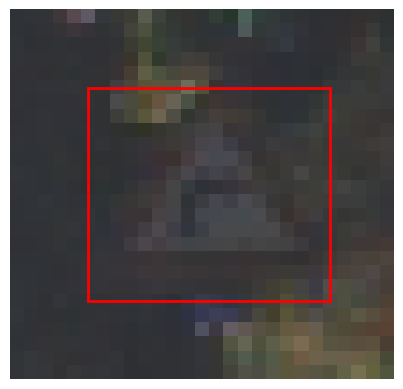

In [7]:
from matplotlib.patches import Rectangle
from matplotlib import pyplot as plt
from PIL import Image

# Select first image
img_data = train_df.iloc[0]

# Collect ROI attributes into a list
roi = [img_data["Roi.X1"], img_data["Roi.Y1"], img_data["Roi.X2"], img_data["Roi.Y2"]]

# Load the image from full_path
img_path = Path(str(img_data["full_path"]))
img = Image.open(img_path).convert("RGB")

# Compute ROI rectangle dimensions
x1, y1, x2, y2 = map(int, roi)
w, h = x2 - x1, y2 - y1

# Plot image with ROI overlay
fig, ax = plt.subplots()
ax.imshow(img)
ax.add_patch(Rectangle((x1, y1), w, h, fill=False, edgecolor="red", linewidth=2))
ax.axis("off")
plt.show()

To get more information about the ROI, for example if there is an error, we add more rows to the datasets

In [8]:
for df in [train_df, test_df]:
      df["roi_w"] = (df["Roi.X2"] - df["Roi.X1"]).clip(lower=1)
      df["roi_h"] = (df["Roi.Y2"] - df["Roi.Y1"]).clip(lower=1)
      df["img_area"] = df["Width"] * df["Height"]
      df["roi_area"] = df["roi_w"] * df["roi_h"]
      df["roi_cover"] = (df["roi_area"] / df["img_area"]).clip(upper=1.0)

train_df.head(3)

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path,full_path,roi_w,roi_h,img_area,roi_area,roi_cover
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png,gtrsb_dataset\1\Train\20\00020_00000_00000.png,17,15,702,255,0.363248
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png,gtrsb_dataset\1\Train\20\00020_00000_00001.png,18,16,756,288,0.380952
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png,gtrsb_dataset\1\Train\20\00020_00000_00002.png,18,16,754,288,0.381963


Run a few quick sanity checks to see if there is any missing data

In [11]:
import os

print("Train rows:", len(train_df), "Test rows:", len(test_df))
print("Classes (train):", train_df["ClassId"].nunique(), "Classes (test):", test_df["ClassId"].nunique())

missing_train = sum(not os.path.exists(p) for p in train_df["full_path"])
missing_test  = sum(not os.path.exists(p) for p in test_df["full_path"])
print("Missing files - train:", missing_train, "test:", missing_test)

Train rows: 39209 Test rows: 12630
Classes (train): 43 Classes (test): 43
Missing files - train: 0 test: 0


We see, that there are no missing files and every class is represented in the train as well as the training data. To get a better understanding, we now take a look at the distribution

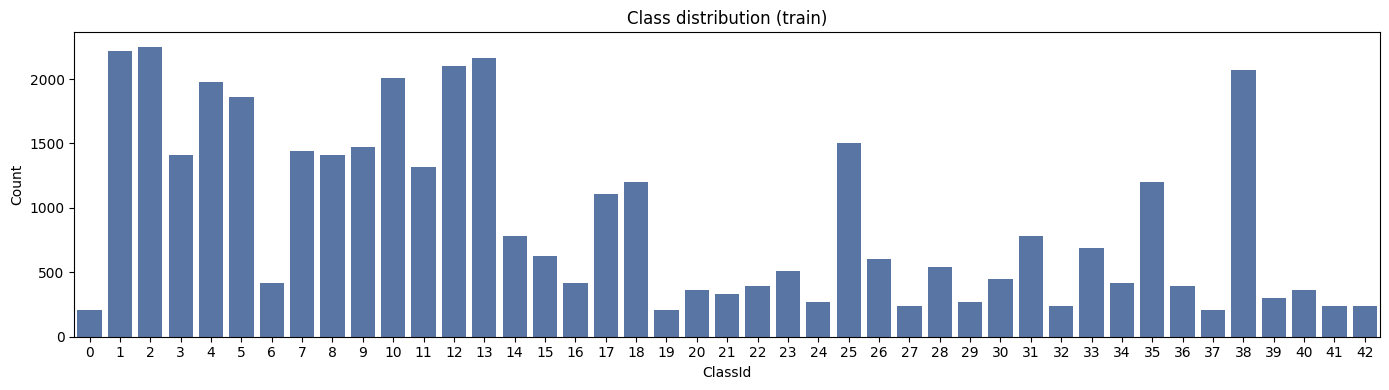

In [12]:
import seaborn as sns

train_counts = train_df["ClassId"].value_counts().sort_index()
plt.figure(figsize=(14,4))
sns.barplot(x=train_counts.index, y=train_counts.values, color="#4C72B0")
plt.title("Class distribution (train)")
plt.xlabel("ClassId")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Now we can see that the dataset is highly dysbalanced.
TODO:
- Train a baseline model and show its bad performance
- Step by step clean the data (sample to get even distribution (maybe oversampling with some augmentation), use ROI to crop images and get everything to same solution, etc.) and show how the model improves for each of the steps
- Try different encoding methods for the images and also try different models. For example would a svm already be sufficient to get a good performance or do we even need a CNN?, use different hyperparameters etc.